# Step 1: Data Preprocessing and Exploratory Behavioral Analysis

In [1]:
# -*- coding: utf-8 -*-
"""
=============================================================================
Script Name: HDDM Data Preprocessing and Exploratory Behavioral Analysis (Step 1)
Description: 
  - Filters and cleans trial-level data for HDDM (Informative Priors).
  - Implements Response Coding Audit to ensure data integrity.
  - Generates Fair-Ceiling Diagnostics focusing on Rejection Rates.
  - Conducts 9:1 vs 8:2 Offer Ratio Robustness Checks.
  - Prepares the final unconstrained matrices for hierarchical modeling.
=============================================================================
"""

import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter, PercentFormatter
from typing import Optional, Tuple

# =============================================================================
# GLOBAL CONSTANTS & CONFIGURATIONS
# =============================================================================
# Visualization aesthetics (APA/Nature standard)
sns.set_theme(style="ticks", palette="colorblind")
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.frameon': False,
    'pdf.fonttype': 42
})

ACC_COLOR = "#004D40"  # Deep sea green
REJ_COLOR = "#900C3F"  # Crimson red (emphasizing rejection)
ACC_ALPHA = 0.52
REJ_ALPHA = 0.75

# Emotion label standardization mappings
EMOTION_LABELS = {
    'aff': 'Affiliative',
    'dis': 'Disgust', 
    'dom': 'Dominance',
    'enj': 'Reward',
    'neu': 'Neutral'
}

EMOTION_FULL_TO_SHORT = {
    "Affiliative": "aff",
    "Disgust": "dis",
    "Dominance": "dom",
    "Reward": "enj",
    "Neutral": "neu"
}

# Reaction Time (RT) boundaries in milliseconds
RT_MIN_MS = 150
RT_MAX_MS = 3000
RT_OUTLIER_THRESHOLD_S = 0.1  # 100ms equivalent in seconds

# Behavioral response coding (Original Data)
RESPONSE_ACCEPT = 1
RESPONSE_REJECT = 2
RESPONSE_NONE = 0

# HDDM response coding
HDDM_ACCEPT = 1
HDDM_REJECT = 0

# Minimum trials threshold
MIN_TRIALS_PER_CONDITION = 15

# =============================================================================
# LOGGING SETUP
# =============================================================================
def setup_logger(log_file: str = "step1_data_preparation.log") -> logging.Logger:
    """Initialize logging configuration for process tracking."""
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s %(levelname)s: %(message)s',
        handlers=[
            logging.FileHandler(log_file, encoding='utf-8'),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

# =============================================================================
# MODULE 1: RESPONSE CODING AUDIT
# =============================================================================
def audit_response_coding(df: pd.DataFrame, logger: logging.Logger) -> pd.DataFrame:
    """
    Strictly audits the mapping between original button presses and HDDM boundaries.
    """
    logger.info("--- Executing Response Coding Audit ---")
    
    # Original counts
    orig_accept = (df['reaction'] == RESPONSE_ACCEPT).sum()
    orig_reject = (df['reaction'] == RESPONSE_REJECT).sum()
    
    # Mapping
    response_mapping = {RESPONSE_ACCEPT: HDDM_ACCEPT, RESPONSE_REJECT: HDDM_REJECT}
    df['response_hddm'] = df['reaction'].map(response_mapping)
    
    # Mapped counts
    hddm_accept = (df['response_hddm'] == HDDM_ACCEPT).sum()
    hddm_reject = (df['response_hddm'] == HDDM_REJECT).sum()
    
    # Validate
    if orig_accept != hddm_accept or orig_reject != hddm_reject:
        raise ValueError("CRITICAL: Response mapping mismatch detected!")
    
    if df['response_hddm'].isnull().any():
        unmapped = df.loc[df['response_hddm'].isnull(), 'reaction'].unique()
        raise ValueError(f"Unmapped response values detected: {unmapped}")
        
    audit_data = [{
        'Original_Response': 'Accept (1)', 'Original_Count': orig_accept,
        'HDDM_Boundary': 'Upper (1)', 'HDDM_Count': hddm_accept
    }, {
        'Original_Response': 'Reject (2)', 'Original_Count': orig_reject,
        'HDDM_Boundary': 'Lower (0)', 'HDDM_Count': hddm_reject
    }]
    
    pd.DataFrame(audit_data).to_csv("response_coding_audit.csv", index=False)
    logger.info("Response coding audit passed and exported to 'response_coding_audit.csv'.")
    return df

# =============================================================================
# MODULE 2: FAIR-CEILING DIAGNOSTICS (Focus: Rejection Rates)
# =============================================================================
def generate_fair_ceiling_diagnostics(df_valid: pd.DataFrame, logger: logging.Logger):
    """
    Calculates and visualizes rejection rates across Fair and Unfair conditions 
    to empirically justify focusing modeling efforts on Unfair trials.
    """
    logger.info("--- Generating Fair-Ceiling Diagnostics ---")
    
    # Define Fair (e.g., Offers >= 4) and Unfair (Offers <= 2)
    df_valid = df_valid.copy()
    df_valid['Condition_Type'] = np.where(df_valid['Offers_You'] <= 2, 'Unfair (9:1, 8:2)', 
                                 np.where(df_valid['Offers_You'] >= 4, 'Fair (5:5, 6:4)', 'Intermediate'))
    
    df_target = df_valid[df_valid['Condition_Type'].isin(['Unfair (9:1, 8:2)', 'Fair (5:5, 6:4)'])]
    
    # Calculate Rejection Rates
    summary = df_target.groupby(['Condition_Type', 'emotion']).apply(
        lambda x: pd.Series({
            'Total_Trials': len(x),
            'Rejection_Rate': (x['reaction'] == RESPONSE_REJECT).mean(),
            'RT_Mean': x['RT'].mean() / 1000.0
        })
    ).reset_index()
    
    summary.to_csv("fair_ceiling_diagnostics.csv", index=False)
    logger.info("Fair-ceiling behavior summary exported to 'fair_ceiling_diagnostics.csv'.")
    
    # Plot Rejection Rates
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=summary, x='emotion', y='Rejection_Rate', hue='Condition_Type',
        palette=['#4A148C', '#900C3F'], alpha=0.85
    )
    plt.title("Empirical Rejection Rates: Fair vs. Unfair Offers", pad=15)
    plt.ylabel("Probability of Rejection")
    plt.xlabel("Emotion Condition")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.ylim(0, 1.05)
    plt.legend(title="Offer Type", loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig("fair_unfair_rejection_rate.pdf", dpi=300)
    plt.close()

# =============================================================================
# MODULE 3: 9:1 VS 8:2 ROBUSTNESS CHECK
# =============================================================================
def generate_offer_ratio_robustness(df_unfair: pd.DataFrame, logger: logging.Logger):
    """
    Validates whether the 9:1 and 8:2 ratios behave similarly enough to merge,
    ensuring emotion effects are robust across extreme inequalities.
    """
    logger.info("--- Generating 9:1 vs 8:2 Robustness Check ---")
    
    summary = df_unfair.groupby(['Offers_You', 'emotion']).apply(
        lambda x: pd.Series({
            'Total_Trials': len(x),
            'Rejection_Rate': (x['reaction'] == RESPONSE_REJECT).mean(),
            'RT_Mean': x['RT'].mean() / 1000.0,
            'RT_Median': x['RT'].median() / 1000.0
        })
    ).reset_index()
    
    summary['Offer_Ratio'] = summary['Offers_You'].map({1: '9:1', 2: '8:2'})
    summary.to_csv("unfair_offer_ratio_behavior_summary.csv", index=False)
    logger.info("Offer ratio robustness check exported to 'unfair_offer_ratio_behavior_summary.csv'.")

# =============================================================================
# DATA LOADING AND FILTERING
# =============================================================================
def load_and_filter_data(filepath: str, logger: logging.Logger) -> pd.DataFrame:
    """Loads raw data, applies exclusion criteria, and triggers diagnostic modules."""
    logger.info(f"Loading raw data from {filepath}")
    
    df = pd.read_csv(filepath)
    logger.info(f"Initial raw data dimensions: {df.shape}")

    exclusion_log = [{'Stage': 'Total_Initial_Trials', 'Count': len(df)}]

    # 1. Missing responses
    omitted_mask = df['reaction'] == RESPONSE_NONE
    df_valid_resp = df[~omitted_mask]
    exclusion_log.append({'Stage': 'Omitted_Responses', 'Count': omitted_mask.sum()})

    # 2. RT boundaries
    fast_mask = df_valid_resp['RT'] < RT_MIN_MS
    df_valid_rt_low = df_valid_resp[~fast_mask]
    exclusion_log.append({'Stage': 'RT_Too_Fast', 'Count': fast_mask.sum()})

    slow_mask = df_valid_rt_low['RT'] > RT_MAX_MS
    df_valid_rt = df_valid_rt_low[~slow_mask]
    exclusion_log.append({'Stage': 'RT_Too_Slow', 'Count': slow_mask.sum()})

    # Trigger Fair-Ceiling Diagnostics BEFORE filtering out fair trials
    generate_fair_ceiling_diagnostics(df_valid_rt, logger)

    # 3. Target Unfair Condition Selection (Offers_You == 1 or 2)
    fair_mask = ~df_valid_rt['Offers_You'].isin([1, 2])
    df_unfair = df_valid_rt[~fair_mask].copy()
    exclusion_log.append({'Stage': 'Non_Unfair_Offers_Excluded', 'Count': fair_mask.sum()})
    exclusion_log.append({'Stage': 'Final_Retained_Unfair_Trials', 'Count': len(df_unfair)})
    
    pd.DataFrame(exclusion_log).to_csv("exclusion_summary_flow.csv", index=False)
    
    logger.info(f"Retained trials (Unfair conditions only): {len(df_unfair)}")
    
    # Trigger Response Audit and Robustness checks on retained data
    df_unfair = audit_response_coding(df_unfair, logger)
    generate_offer_ratio_robustness(df_unfair, logger)

    return df_unfair

def _normalize_emotion_values(col: pd.Series) -> pd.Series:
    return col.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

# =============================================================================
# HDDM DATA STRUCTURING
# =============================================================================
def prepare_hddm_data(df: pd.DataFrame, logger: logging.Logger) -> pd.DataFrame:
    """Constructs the data matrix required for PyMC/HDDM estimation."""
    df = df.copy()
    df['emotion'] = _normalize_emotion_values(df['emotion']).replace(EMOTION_FULL_TO_SHORT)
    
    if 'subject' in df.columns:
        df = df.drop(columns=['subject'])
        
    unique_ids = df['participant_id'].unique()
    id_map = {orig_id: idx for idx, orig_id in enumerate(unique_ids)}
    df['subj_idx'] = df['participant_id'].map(id_map)
    
    pd.DataFrame(list(id_map.items()), columns=['Original_participant_id', 'HDDM_subj_idx']).to_csv('subject_mapping.csv', index=False)

    hddm_df = pd.DataFrame({
        'subj_idx': df['subj_idx'],
        'rt': df['RT'] / 1000.0,
        'response': df['response_hddm'],
        'emotion': df['emotion'],
        'offer_amount': df['Offers_You']
    })

    return hddm_df

# =============================================================================
# PUBLICATION-READY VISUALIZATIONS
# =============================================================================
def create_rt_distribution_plot(df: pd.DataFrame, output_file: str = "rt_mirror_distributions.pdf"):
    """Generates mirrored RT histograms (Rejection vs Acceptance)."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Condition-wise Mirrored RT Distribution (Unfair Offers)', fontsize=16, fontweight='bold', y=1.02)
    axes_flat = axes.flatten()
    
    plot_mirror_histogram(df, axes_flat[0], 'Overall')
    
    emotions = sorted(df['emotion'].unique())
    for idx, emo in enumerate(emotions):
        plot_mirror_histogram(df[df['emotion'] == emo], axes_flat[idx + 1], EMOTION_LABELS.get(emo, emo))
    
    for j in range(len(emotions) + 1, 6):
        axes_flat[j].axis('off')
    
    handles = [
        mpatches.Patch(facecolor=REJ_COLOR, alpha=REJ_ALPHA, label='Rejected'),
        mpatches.Patch(facecolor=ACC_COLOR, alpha=ACC_ALPHA, label='Accepted'),
    ]
    fig.legend(handles, ['Rejected', 'Accepted'], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.94])
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close()

def plot_mirror_histogram(data: pd.DataFrame, ax, title: str):
    accepted = data[data['response'] == 1]['rt']
    rejected = data[data['response'] == 0]['rt']
    bins = np.linspace(0, 2.5, 30)
    
    hist_acc, _ = np.histogram(accepted, bins=bins)
    hist_rej, _ = np.histogram(rejected, bins=bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    width = bins[1] - bins[0]
    
    ax.barh(bin_centers, hist_acc, height=width*0.8, alpha=ACC_ALPHA, facecolor=ACC_COLOR)
    ax.barh(bin_centers, -hist_rej, height=width*0.8, alpha=REJ_ALPHA, facecolor=REJ_COLOR)
    
    ax.set_title(title, pad=5)
    ax.set_ylabel('Reaction Time (s)')
    ax.set_xlabel('Frequency')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(abs(x))}'))

# =============================================================================
# PIPELINE EXECUTION
# =============================================================================
def main():
    logger = setup_logger()
    logger.info("="*60)
    logger.info("HDDM DATA PREPARATION PIPELINE INITIATED (Informative Priors)")
    logger.info("="*60)
    
    try:
        input_file = 'trials.csv'
        df_unfair = load_and_filter_data(input_file, logger)
        hddm_df = prepare_hddm_data(df_unfair, logger)
        
        logger.info("Generating visualization assets...")
        create_rt_distribution_plot(hddm_df)
        
        output_file = 'hddm_data_unfair.csv'
        hddm_df.to_csv(output_file, index=False)
        logger.info(f"Final analytical dataset committed to {output_file}")
        
    except Exception as e:
        logger.error(f"Fatal error encountered: {e}")
        raise

if __name__ == "__main__":
    main()

2026-03-22 12:00:21,400 INFO: ============================================================
2026-03-22 12:00:21,401 INFO: HDDM DATA PREPARATION PIPELINE INITIATED (Informative Priors)
2026-03-22 12:00:21,402 INFO: ============================================================
2026-03-22 12:00:21,403 INFO: Loading raw data from trials.csv
2026-03-22 12:00:21,447 INFO: Initial raw data dimensions: (16197, 15)
2026-03-22 12:00:21,453 INFO: --- Generating Fair-Ceiling Diagnostics ---
2026-03-22 12:00:21,479 INFO: Fair-ceiling behavior summary exported to 'fair_ceiling_diagnostics.csv'.
2026-03-22 12:00:21,674 INFO: maxp pruned
2026-03-22 12:00:21,685 INFO: cmap pruned
2026-03-22 12:00:21,687 INFO: kern dropped
2026-03-22 12:00:21,688 INFO: post pruned
2026-03-22 12:00:21,691 INFO: FFTM dropped
2026-03-22 12:00:21,696 INFO: GPOS pruned
2026-03-22 12:00:21,702 INFO: GSUB pruned
2026-03-22 12:00:21,704 INFO: name pruned
2026-03-22 12:00:21,715 INFO: glyf pruned
2026-03-22 12:00:21,719 INFO: Adde

2026-03-22 12:00:21,862 INFO: Closed glyph list over 'glyf': 54 glyphs after
2026-03-22 12:00:21,863 INFO: Glyph names: ['.notdef', '.null', 'C', 'E', 'F', 'O', 'P', 'R', 'T', 'U', 'a', 'b', 'c', 'colon', 'comma', 'd', 'e', 'eight', 'f', 'fi', 'five', 'fl', 'four', 'i', 'j', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'r', 's', 'six', 'space', 't', 'two', 'u', 'uni239B', 'uni239C', 'uni239D', 'uni239E', 'uni239F', 'uni23A0', 'uniFB00', 'uniFB03', 'uniFB04', 'y', 'zero']
2026-03-22 12:00:21,865 INFO: Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 15, 19, 20, 21, 23, 24, 25, 27, 28, 29, 38, 40, 41, 50, 51, 53, 55, 56, 68, 69, 70, 71, 72, 73, 76, 77, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92, 3506, 3507, 3508, 3509, 3510, 3511, 5038, 5039, 5040, 5041, 5042]
2026-03-22 12:00:21,867 INFO: Retaining 54 glyphs
2026-03-22 12:00:21,869 INFO: head subsetting not needed
2026-03-22 12:00:21,870 INFO: hhea subsetting not needed
2026-03-22 12:00:21,872 INFO: 

2026-03-22 12:00:23,246 INFO: Glyph names: ['.notdef', '.null', 'A', 'F', 'R', 'T', 'a', 'c', 'd', 'e', 'five', 'four', 'i', 'j', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'q', 'r', 's', 'seven', 'six', 'space', 't', 'two', 'u', 'y', 'zero']
2026-03-22 12:00:23,248 INFO: Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 23, 24, 25, 26, 36, 41, 53, 55, 68, 70, 71, 72, 76, 77, 80, 81, 82, 83, 84, 85, 86, 87, 88, 92]
2026-03-22 12:00:23,249 INFO: Closed glyph list over 'MATH': 40 glyphs after
2026-03-22 12:00:23,250 INFO: Glyph names: ['.notdef', '.null', 'A', 'F', 'R', 'T', 'a', 'c', 'd', 'e', 'five', 'four', 'i', 'j', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'q', 'r', 's', 'seven', 'six', 'space', 't', 'two', 'u', 'uni239B', 'uni239C', 'uni239D', 'uni239E', 'uni239F', 'uni23A0', 'y', 'zero']
2026-03-22 12:00:23,251 INFO: Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 23, 24, 25, 26, 36, 41, 53, 55, 6

# Step 2a: Global Configuration

In [3]:
%%writefile hddm_config.py
# -*- coding: utf-8 -*-
"""
=============================================================================
Module Name: Centralized HDDM Configuration (Step 2a - Publication Standard)
Description: 
  - Auto-generated by Jupyter Notebook via %%writefile magic.
  - Upgraded to meet rigorous publication standards (Pan et al. methodology).
  - Encodes strict Two-Tier convergence criteria (R-hat, ESS, MCSE).
  - Introduces quantitative PPC (Posterior Predictive Check) thresholds.
  - Distinguishes 'Standard' (stable, DIC+PPC) from 'Enhanced' (WAIC/LOO, optional).
=============================================================================
"""

import sys
import json
import platform
import importlib
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List

@dataclass
class HDDMConfig:
    """
    Global configuration schema for hierarchical Bayesian estimation.
    """
    # -------------------------------------------------------------------------
    # 1. FILE HANDLING & HIERARCHY
    # -------------------------------------------------------------------------
    data_file: str = 'hddm_data_unfair.csv'
    hierarchy: str = 'full'
    prior_type: str = 'informative'
    use_informative_priors: bool = True
    
    # -------------------------------------------------------------------------
    # 2. RUN MODE & MCMC ESTIMATION PARAMETERS
    # -------------------------------------------------------------------------
    run_mode: str = 'debug'  #final or debug
    n_chains: int = 6
    n_samples: int = 5000
    n_burn: int = 1000
    thin: int = 2
    base_seed: int = 2508
    p_outlier: float = 0.05
    
    # -------------------------------------------------------------------------
    # 3. EXPERIMENTAL DESIGN & RESPONSE CODING
    # -------------------------------------------------------------------------
    baseline_condition: str = 'neu'
    emotions: List[str] = field(default_factory=lambda: ['aff', 'dis', 'dom', 'enj', 'neu'])
    
    # -------------------------------------------------------------------------
    # 4. THEORETICAL MODEL SPACE & PARAMETER INTERPRETATION
    # -------------------------------------------------------------------------
    core_models: List[str] = field(default_factory=lambda: ['null', 'v', 'a', 'va'])
    exploratory_models: List[str] = field(default_factory=lambda: ['vz', 'vt'])
    
    # Strict separation of parameter interpretation for publication reporting
    primary_parameters: List[str] = field(default_factory=lambda: ['v', 'a'])
    exploratory_parameters: List[str] = field(default_factory=lambda: ['z', 't'])

    # -------------------------------------------------------------------------
    # 5. DIAGNOSTICS THRESHOLDS (Tier 1 & Tier 2)
    # -------------------------------------------------------------------------
    # Tier 1: Eligibility (Minimum bar to enter DIC comparison)
    rhat_eligible: float = 1.05
    ess_eligible: float = 200.0
    mcse_eligible: float = 0.05  # Max allowed MCSE proportion relative to posterior SD

    # Tier 2: Publication-Ready Strict Standard (Modern rigorous bar)
    rhat_strict: float = 1.01
    ess_strict: float = 400.0
    mcse_strict: float = 0.01

    # -------------------------------------------------------------------------
    # 6. PPC ADEQUACY THRESHOLDS (Quantitative Model Checking)
    # -------------------------------------------------------------------------
    # Defines what constitutes a "Pass" for Absolute Fit
    ppc_choice_mae_max: float = 0.05      # Max Mean Absolute Error for choice rates (e.g., 5%)
    ppc_choice_max_err: float = 0.10      # Max absolute error allowed in any single condition
    ppc_rt_quantile_mae_max: float = 0.05 # Max MAE for RT quantiles (seconds)
    ppc_rt_quantile_max_err: float = 0.10 # Max absolute error allowed for any RT quantile
    ppc_total_samples: int = 500          # Total posterior predictive simulations
    
    # -------------------------------------------------------------------------
    # 7. RECOVERY CONFIGURATION
    # -------------------------------------------------------------------------
    recovery_sd_link_v: float = 0.1
    recovery_sd_link_a: float = 0.1
    recovery_sd_link_t: float = 0.1
    recovery_sd_link_z: float = 0.1

    def __post_init__(self):
        if self.run_mode == 'debug':
            self.n_chains = 2
            self.n_samples = 500
            self.n_burn = 100
            self.thin = 1
            self.ppc_total_samples = 50
            print("\n[CONFIG WARNING] Operating in DEBUG mode. MCMC severely reduced.\n")

    @property
    def output_dir(self) -> Path:
        d = Path(f'hddm_models_{self.prior_type}_{self.hierarchy}')
        d.mkdir(parents=True, exist_ok=True)
        return d

    def export_environment_metadata(self):
        metadata = {
            "System_Architecture": platform.platform(),
            "Python_Version": sys.version,
            "Run_Mode": self.run_mode,
            "Configuration_Snapshot": asdict(self)
        }
        out_path = self.output_dir / "analysis_config_snapshot.json"
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump(metadata, f, indent=4)
        print(f"[CONFIG] Standard Publication configuration loaded (Mode: {self.run_mode.upper()}).")
        print(f"[CONFIG] Environment metadata exported to: {out_path}")

CFG = HDDMConfig()
if __name__ == "__main__":
    CFG.export_environment_metadata()

Overwriting hddm_config.py


# Step 2b: Hierarchical Bayesian Model Specification and MCMC Estimation

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
Script Name: HDDM Hierarchical Regression Modeling Pipeline (Step 2b)
Description: 
  - Upgraded to 'Standard Publication' tier.
  - Executes multi-chain MCMC estimation with extreme memory safety.
  - EXPLICITLY sets keep_regressor_trace=False and avoids WAIC/LOO to 
    guarantee computational stability for the main publication pipeline.
  - Implements MAP initialization tracking to assess model identifiability.
  - Retains DIC as the primary relative comparison metric (Adequacy will be 
    handled by PPC in later steps).
=============================================================================
"""

import os
import gc
import time
import logging
from datetime import datetime
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import hddm

# -----------------------------------------------------------------------------
# SAFEGUARD: PERSISTENT CONFIGURATION IMPORT
# -----------------------------------------------------------------------------
try:
    from hddm_config import CFG
except ImportError:
    raise ImportError(
        "CRITICAL ERROR: 'hddm_config.py' not found on disk. "
        "Please run Step 2a at least once to generate it."
    )

# =============================================================================
# LOGGING SETUP
# =============================================================================
def _setup_logger() -> logging.Logger:
    """Initialize standardized logging for process tracking."""
    os.makedirs('logs', exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    logger = logging.getLogger(f'hddm_{CFG.hierarchy}_{ts}')
    logger.handlers = []
    logger.setLevel(logging.INFO)
    fmt = logging.Formatter('%(asctime)s - %(message)s', datefmt='%H:%M:%S')
    
    fh = logging.FileHandler(f'logs/hddm_estimation_{CFG.hierarchy}_{ts}.log', encoding='utf-8')
    ch = logging.StreamHandler()
    fh.setFormatter(fmt)
    ch.setFormatter(fmt)
    
    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger

# =============================================================================
# CORE CLASS
# =============================================================================
class HDDMHierarchicalFitter:
    
    def __init__(self):
        self.logger = _setup_logger()
        self.models_dir = CFG.output_dir
        self.start_fail_log: List[Dict] = []
        
        self.logger.info("=" * 70)
        self.logger.info("HDDM FULL EXHAUSTIVE MODEL FITTER INITIATED (STANDARD PUBLICATION TIER)")
        self.logger.info(f"Target Hierarchy: {CFG.hierarchy.upper()}")
        self.logger.info(f"MCMC Protocol:    Samples={CFG.n_samples}, Burn={CFG.n_burn}, Chains={CFG.n_chains}")
        self.logger.info("=" * 70)

    def _save_name(self, model_flag: str) -> str:
        """Standardize output naming conventions."""
        suffix = f'_inf_{CFG.hierarchy}'
        return f"{model_flag}_emotion{suffix}" if model_flag != 'null' else f"null_model{suffix}"

    def validate_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """Enforces datatype constraints and removes missing observations."""
        df = df.copy()
        df['subj_idx'] = df['subj_idx'].astype(str)
        df['emotion'] = df['emotion'].astype(str)
        df['rt'] = pd.to_numeric(df['rt'], errors='coerce')
        df['response'] = pd.to_numeric(df['response'], errors='coerce')
        
        initial_len = len(df)
        df = df.dropna(subset=['rt', 'response'])
        dropped = initial_len - len(df)
        
        if dropped > 0:
            self.logger.warning(f"Data validation: Dropped {dropped} trials containing NaN values.")
            
        ems = sorted(pd.unique(df['emotion']))
        if CFG.baseline_condition not in ems:
            self.logger.warning(f"Baseline '{CFG.baseline_condition}' not found in data. Verify configuration.")
        
        self.logger.info(f"Using reference baseline condition: {CFG.baseline_condition}")
        return df

    def _build_model(self, df: pd.DataFrame, model_flag: str) -> hddm.HDDMRegressor:
        """Dynamic constructor for requested regression formulas."""
        # PUBLICATION STANDARD: Keep regressor trace FALSE to prevent memory explosion.
        # Random slopes are intentionally excluded from the standard tier to ensure stability.
        base_args = {
            'include': ['v', 'a', 't', 'z'],
            'is_group_model': True,
            'keep_regressor_trace': False, 
            'p_outlier': CFG.p_outlier,
            'informative': CFG.use_informative_priors
        }
        
        # Apply Treatment coding to define reference level dynamically
        ref = f'C(emotion, Treatment("{CFG.baseline_condition}"))'
        
        formulas = {
            'null': ['v~1', 'a~1', 't~1', 'z~1'],
            'v':    [f'v~{ref}', 'a~1', 't~1', 'z~1'],
            'a':    ['v~1', f'a~{ref}', 't~1', 'z~1'],
            'va':   [f'v~{ref}', f'a~{ref}', 't~1', 'z~1'],
            'vz':   [f'v~{ref}', 'a~1', 't~1', f'z~{ref}'],
            'vt':   [f'v~{ref}', 'a~1', f't~{ref}', 'z~1']
        }
        
        if model_flag not in formulas:
            raise ValueError(f"Model {model_flag} is not supported in the optimized pipeline.")
            
        return hddm.HDDMRegressor(df, formulas[model_flag], **base_args)

    def fit_single_model(self, df: pd.DataFrame, model_flag: str) -> Tuple[bool, Optional[Dict]]:
        """Executes multi-chain MCMC for a discrete regression model."""
        save_name = self._save_name(model_flag)
        model_dir = self.models_dir / save_name
        model_dir.mkdir(parents=True, exist_ok=True)
        
        self.logger.info(f"\nConstructing graphical model structure: {model_flag}")
        dic_scores = []
        
        for chain_idx in range(CFG.n_chains):
            chain_seed = CFG.base_seed + chain_idx
            np.random.seed(chain_seed)
            self.logger.info(f"  -> Initiating Chain {chain_idx + 1}/{CFG.n_chains} [Seed: {chain_seed}]")
            
            model = self._build_model(df, model_flag)

            # MAP Initialization tracking to assess structural identifiability
            map_failed = False
            try: 
                model.find_starting_values()
            except Exception: 
                map_failed = True
                self.logger.warning(f"     [Warning] MAP optimization failed. Falling back to prior bounds.")
            
            self.start_fail_log.append({
                "Model": model_flag,
                "Chain": chain_idx,
                "Seed": chain_seed,
                "MAP_Initialization_Failed": map_failed
            })

            db_path = str(model_dir / f"{save_name}_chain_{chain_idx}.db")
            
            start_time = time.time()
            try:
                model.sample(CFG.n_samples, burn=CFG.n_burn, 
                             thin=CFG.thin, dbname=db_path, db='pickle')
            except Exception as e:
                self.logger.error(f"     [Fatal] Sampling error in chain {chain_idx}: {e}")
                return False, None
            
            elapsed_mins = (time.time() - start_time) / 60
            self.logger.info(f"     Chain {chain_idx + 1} completed in {elapsed_mins:.1f} mins.")
            
            try: 
                dic_scores.append(float(model.dic))
            except Exception: 
                pass

            model.save(str(model_dir / f"{save_name}_chain_{chain_idx}.hddm"))
            
            # Aggressive memory safeguard implementation
            try: 
                model.db.close()
            except Exception: 
                pass
            del model
            gc.collect()

        mean_dic = float(np.nanmean(dic_scores)) if dic_scores else None
        return True, {'name': save_name, 'dic': mean_dic}

    def run(self, df: pd.DataFrame) -> Dict:
        """Iterates through partitioned theoretical space and exports diagnostic metadata."""
        df = self.validate_data(df)
        
        all_models = CFG.core_models + CFG.exploratory_models
        out = {'successful': [], 'failed': [], 'dics': {}}
        
        for i, m in enumerate(all_models, 1):
            category = "CORE" if m in CFG.core_models else "EXPLORATORY"
            self.logger.info(f"\n{'='*50}\nProcessing Model {i}/{len(all_models)}: [{m}] ({category})\n{'='*50}")
            
            ok, res = self.fit_single_model(df, m)
            if ok and res is not None:
                out['successful'].append(res['name'])
                if res.get('dic') is not None: 
                    out['dics'][res['name']] = res['dic']
            else: 
                out['failed'].append(m)
                
        # Export MAP Initialization failure logs for downstream analysis
        fail_df = pd.DataFrame(self.start_fail_log)
        fail_path = CFG.output_dir / "map_initialization_report.csv"
        fail_df.to_csv(fail_path, index=False)
        self.logger.info(f"\nMAP initialization audit trail exported to: {fail_path.name}")
        
        return out

# =============================================================================
# PIPELINE EXECUTION
# =============================================================================
if __name__ == "__main__":
    try:
        data_df = pd.read_csv(CFG.data_file)
        fitter = HDDMHierarchicalFitter()
        results = fitter.run(data_df)
        
        print("\n[STANDARD MODEL ESTIMATION SUMMARY - DIC ONLY]:")
        print("Note: Final selection will be governed by Step 4 (Strict Convergence + PPC Adequacy).")
        for name, dic in sorted(results['dics'].items(), key=lambda x: x[1]):
            print(f" {name:30s} DIC = {dic:10.2f}")
            
    except FileNotFoundError:
        print(f"CRITICAL ERROR: Data file '{CFG.data_file}' not found. Verify working directory.")

12:03:30 - ======================================================================
2026-03-22 12:03:30,997 INFO: ======================================================================
12:03:30 - HDDM FULL EXHAUSTIVE MODEL FITTER INITIATED (STANDARD PUBLICATION TIER)
2026-03-22 12:03:30,999 INFO: HDDM FULL EXHAUSTIVE MODEL FITTER INITIATED (STANDARD PUBLICATION TIER)
12:03:31 - Target Hierarchy: FULL
2026-03-22 12:03:31,001 INFO: Target Hierarchy: FULL
12:03:31 - MCMC Protocol:    Samples=500, Burn=100, Chains=2
2026-03-22 12:03:31,004 INFO: MCMC Protocol:    Samples=500, Burn=100, Chains=2
12:03:31 - ======================================================================
2026-03-22 12:03:31,006 INFO: ======================================================================
12:03:31 - Using reference baseline condition: neu
2026-03-22 12:03:31,013 INFO: Using reference baseline condition: neu
12:03:31 - 
Processing Model 1/6: [null] (CORE)
2026-03-22 12:03:31,016 INFO: 
Processing Model 1/6:


[CONFIG WARNING] Operating in DEBUG mode. MCMC severely reduced.

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [                  1%                  ] 8 of 500 complete in 7.9 sec

# Step 3: Posterior Trace Extraction and Predictive Simulation

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
Script Name: HDDM to ArviZ InferenceData Converter & PPC Generator (Step 3)
Description: 
  - Upgraded to 'Standard Publication' tier.
  - Iteratively loads multi-chain HDDM models generated in Step 2b.
  - Extracts posterior traces and enforces strict dimensional structures 
    (Chain, Draw, Parameter) required for robust Bayesian diagnostics.
  - Automatically generates Posterior Predictive Checks (PPC) data 
    (rt_sampled, response_sampled) and aligns it with condition metadata.
  - Aggregates all structures into a memory-efficient ArviZ NetCDF object.
=============================================================================
"""

import os
import gc
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import arviz as az

# Suppress runtime warnings from PyMC/Theano legacy backends
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# SAFEGUARD: PERSISTENT CONFIGURATION IMPORT
# -----------------------------------------------------------------------------
try:
    from hddm_config import CFG
except ImportError:
    raise ImportError(
        "CRITICAL ERROR: 'hddm_config.py' not found on disk. "
        "Execute Step 2a to generate the global configuration."
    )

try:
    import hddm
except ImportError:
    raise ImportError("HDDM dependency missing. Verify execution environment.")

# =============================================================================
# DIRECTORY CONFIGURATION & PPC ALLOCATION
# =============================================================================
INPUT_ROOT = CFG.output_dir
OUTPUT_ROOT = Path(f'bayesian_results_netcdf_{CFG.prior_type}_{CFG.hierarchy}')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

ALL_MODELS = CFG.core_models + CFG.exploratory_models

# Enforce dynamic PPC allocation from global configuration
PPC_SAMPLES_PER_CHAIN = max(1, CFG.ppc_total_samples // CFG.n_chains)

# =============================================================================
# LOGGING SETUP
# =============================================================================
def setup_extraction_logger() -> logging.Logger:
    """Initializes standardized logging for the MCMC extraction process."""
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    logger = logging.getLogger(f'hddm_arviz_convert_{ts}')
    logger.handlers = []
    logger.setLevel(logging.INFO)
    
    fmt = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%H:%M:%S')
    fh = logging.FileHandler(OUTPUT_ROOT / f'arviz_conversion_{ts}.log', encoding='utf-8')
    ch = logging.StreamHandler()
    fh.setFormatter(fmt)
    ch.setFormatter(fmt)
    
    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger

# =============================================================================
# CONVERTER ENGINE
# =============================================================================
class HDDMArvizConverter:
    """Handles multi-chain extraction, dimensional alignment, and NetCDF serialization."""

    def __init__(self):
        self.logger = setup_extraction_logger()
        
        self.logger.info("=" * 70)
        self.logger.info("HDDM MULTI-CHAIN EXTRACTION & ARVIZ COMPILATION (STANDARD TIER)")
        self.logger.info(f"Target Hierarchy: {CFG.hierarchy.upper()}")
        self.logger.info(f"Active Chains:    {CFG.n_chains}")
        self.logger.info(f"PPC Protocol:     {CFG.ppc_total_samples} total samples ({PPC_SAMPLES_PER_CHAIN}/chain)")
        self.logger.info("=" * 70)

    def _filter_trace_columns(self, traces_df: pd.DataFrame) -> List[str]:
        """
        Identifies functional parameter columns to retain.
        Purges deterministic trial-level likelihood nodes and internal MCMC states 
        to mitigate geometric memory scaling.
        """
        valid_cols = []
        for col in traces_df.columns:
            if col.startswith(('wfpt', 'mc_', '__')):
                continue
            valid_cols.append(col)
        return valid_cols

    def process_model_chains(self, model_flag: str):
        """
        Executes sequential chain loading, array aggregation, and NetCDF compilation.
        """
        dirname = f"{model_flag}_model" if model_flag == 'null' else f"{model_flag}_emotion"
        target_dir = INPUT_ROOT / dirname
        out_file = OUTPUT_ROOT / f"{dirname}_arviz.nc"
        
        if out_file.exists():
            self.logger.info(f"Skipping [{model_flag}]: Compiled ArviZ NetCDF already exists.")
            return

        self.logger.info(f"\nProcessing Compilation for [{model_flag}] -> {dirname}")
        
        posterior_arrays: Dict[str, List[np.ndarray]] = {}
        ppc_rt_list: List[np.ndarray] = []
        ppc_resp_list: List[np.ndarray] = []
        
        observed_dict: Optional[Dict[str, np.ndarray]] = None
        dic_scores = []
        
        for chain_idx in range(CFG.n_chains):
            model_file = target_dir / f"{dirname}_chain_{chain_idx}.hddm"
            
            if not model_file.exists():
                self.logger.error(f"  [ERROR] Missing chain artifact: {model_file.name}. Pipeline aborted for this model.")
                return

            self.logger.info(f"  -> Ingesting Chain {chain_idx + 1}/{CFG.n_chains} into RAM...")
            
            try:
                model = hddm.load(str(model_file))
                
                try: 
                    dic_scores.append(float(model.dic))
                except Exception: 
                    pass

                traces_df = model.get_traces()
                
                if chain_idx == 0:
                    valid_params = self._filter_trace_columns(traces_df)
                    posterior_arrays = {p: [] for p in valid_params}
                    self.logger.info(f"     Identified {len(valid_params)} distinct inference parameters.")
                
                for param in valid_params:
                    arr = traces_df[param].values.astype(np.float32)
                    posterior_arrays[param].append(arr)

                self.logger.info(f"     Simulating PPC distributions (Samples: {PPC_SAMPLES_PER_CHAIN})...")
                
                # append_data=True is CRITICAL to retain categorical emotion labels
                ppc_df = hddm.utils.post_pred_gen(model, samples=PPC_SAMPLES_PER_CHAIN, append_data=True)
                
                n_trials = len(ppc_df)
                rt_sim = np.zeros((n_trials, PPC_SAMPLES_PER_CHAIN), dtype=np.float32)
                resp_sim = np.zeros((n_trials, PPC_SAMPLES_PER_CHAIN), dtype=np.int8)
                
                for i in range(n_trials):
                    rt_sim[i, :] = ppc_df.iloc[i]['rt_sampled']
                    resp_sim[i, :] = np.round(ppc_df.iloc[i]['response_sampled']).astype(np.int8)
                
                ppc_rt_list.append(rt_sim.T)
                ppc_resp_list.append(resp_sim.T)
                
                # Capture empirical observations and experimental condition metadata
                if observed_dict is None:
                    observed_dict = {
                        'rt': ppc_df['rt'].values.astype(np.float32),
                        'response': ppc_df['response'].values.astype(np.int8),
                        'emotion': ppc_df['emotion'].values.astype(str)
                    }

            except Exception as e:
                self.logger.error(f"     [FATAL] Failure parsing chain {chain_idx}: {e}")
                import traceback
                self.logger.debug(traceback.format_exc())
                return
                
            finally:
                # Explicit memory deallocation to prevent sequential OOM crashes
                if 'model' in locals():
                    try:
                        if hasattr(model, 'db') and hasattr(model.db, 'close'):
                            model.db.close()
                    except Exception:
                        pass
                    del model
                if 'ppc_df' in locals(): del ppc_df
                if 'traces_df' in locals(): del traces_df
                gc.collect()

        self.logger.info("  Aggregating dimensional arrays and constructing NetCDF...")
        
        try:
            # Stack arrays along the chain dimension (axis=0)
            final_posterior = {}
            for param, chain_list in posterior_arrays.items():
                final_posterior[param] = np.stack(chain_list, axis=0)

            final_ppc = {
                'rt': np.stack(ppc_rt_list, axis=0),
                'response': np.stack(ppc_resp_list, axis=0)
            }

            idata = az.from_dict(
                posterior=final_posterior,
                posterior_predictive=final_ppc,
                observed_data=observed_dict
            )
            
            # Attach operational metadata to the InferenceData object
            idata.posterior.attrs['model_identifier'] = dirname
            idata.posterior.attrs['hierarchy_type'] = CFG.hierarchy
            idata.posterior.attrs['compilation_timestamp'] = datetime.now().isoformat()
            if dic_scores:
                idata.posterior.attrs['dic_score'] = float(np.nanmean(dic_scores))

            self.logger.info("  Serializing InferenceData object...")
            idata.to_netcdf(str(out_file))
            
            file_size_mb = out_file.stat().st_size / (1024 * 1024)
            self.logger.info(f"  [SUCCESS] Compiled {out_file.name} ({file_size_mb:.1f} MB)")
            
        except Exception as e:
            self.logger.error(f"  [FATAL] Error during ArviZ compilation: {e}")

    def run_pipeline(self):
        """Orchestrates extraction sequence across the theoretical model space."""
        if not INPUT_ROOT.exists():
            self.logger.error(f"Critical Path Error: Input directory missing -> {INPUT_ROOT}")
            return
            
        for model_flag in ALL_MODELS:
            self.process_model_chains(model_flag)
            
        self.logger.info("\n" + "=" * 70)
        self.logger.info("ALL EXTRACTION AND SIMULATION TASKS COMPLETED SUCCESSFULLY")
        self.logger.info("=" * 70)

# =============================================================================
# PIPELINE EXECUTION
# =============================================================================
if __name__ == "__main__":
    converter = HDDMArvizConverter()
    converter.run_pipeline()

17:27:01 - INFO - ======================================================================
17:27:01 - INFO - HDDM MULTI-CHAIN EXTRACTION & ARVIZ COMPILATION INITIATED
17:27:01 - INFO - Target Hierarchy: FULL
17:27:01 - INFO - Expected Chains:  6
17:27:01 - INFO - ======================================================================
17:27:01 - INFO - 
Processing Compilation for [null] -> null_model_inf_full
17:27:01 - ERROR -   [ERROR] Missing chain artifact: null_model_inf_full_chain_0.hddm. Pipeline aborted for this model.
17:27:01 - INFO - 
Processing Compilation for [v] -> v_emotion_inf_full
17:27:01 - INFO -   -> Ingesting Chain 1/6 into RAM...
17:27:06 - INFO -      Identified 256 distinct parameters. Trace length: 133.
17:27:06 - INFO -      Simulating PPC distributions (Samples: 100)...


Start generating posterior prediction...


17:29:52 - INFO -   -> Ingesting Chain 2/6 into RAM...
17:29:56 - INFO -      Simulating PPC distributions (Samples: 100)...


Start generating posterior prediction...


17:32:36 - INFO -   -> Ingesting Chain 3/6 into RAM...
17:32:41 - INFO -      Simulating PPC distributions (Samples: 100)...


...

17:55:39 - INFO -   -> Ingesting Chain 5/6 into RAM...
17:55:44 - INFO -      Simulating PPC distributions (Samples: 100)...


Start generating posterior prediction...


17:58:23 - INFO -   -> Ingesting Chain 6/6 into RAM...
17:58:27 - INFO -      Simulating PPC distributions (Samples: 100)...


Start generating posterior prediction...


18:01:05 - INFO -   Aggregating dimensional arrays and constructing NetCDF...
18:01:06 - INFO -   Serializing InferenceData object...
18:02:34 - INFO -   [SUCCESS] Compiled a_emotion_inf_full_arviz.nc (1236.0 MB)
18:02:34 - INFO - 
Processing Compilation for [va] -> va_emotion_inf_full
18:02:34 - ERROR -   [ERROR] Missing chain artifact: va_emotion_inf_full_chain_0.hddm. Pipeline aborted for this model.
18:02:34 - INFO - 
Processing Compilation for [vz] -> vz_emotion_inf_full
18:02:34 - ERROR -   [ERROR] Missing chain artifact: vz_emotion_inf_full_chain_0.hddm. Pipeline aborted for this model.
18:02:34 - INFO - 
Processing Compilation for [vt] -> vt_emotion_inf_full
18:02:34 - ERROR -   [ERROR] Missing chain artifact: vt_emotion_inf_full_chain_0.hddm. Pipeline aborted for this model.
18:02:34 - INFO - 
Processing Compilation for [vaz] -> vaz_emotion_inf_full
18:02:34 - ERROR -   [ERROR] Missing chain artifact: vaz_emotion_inf_full_chain_0.hddm. Pipeline aborted for this model.
18:02:34

# Step 4: Convergence Diagnostics and Model Selection

09:39:17 - INFO - ======================================================================
09:39:17 - INFO - MULTI-CHAIN BAYESIAN DIAGNOSTICS & MODEL COMPARISON INITIALIZED
09:39:17 - INFO - Target Directory: bayesian_results/analysis_netcdf_inf_full
09:39:17 - INFO - ======================================================================
09:39:17 - INFO - Discovered 2 NetCDF models. Initiating ingestion...
09:39:19 - INFO -   [Loaded] a_emotion_inf_full | Chains: 6
09:39:21 - INFO -   [Loaded] v_emotion_inf_full | Chains: 6
09:39:21 - INFO - 
Executing Multi-Chain Convergence Diagnostics (R-hat & ESS)...
09:39:21 - INFO -   Diagnosing a_emotion_inf_full...
09:39:24 - WARNING -     [!] Divergence detected. Problematic nodes: ['v_Intercept', 'v_Intercept_std', 'v_Intercept_subj.0', 'v_Intercept_subj.10', 'v_Intercept_subj.11']...
09:39:24 - INFO -   Diagnosing v_emotion_inf_full...
09:39:26 - WARNING -     [!] Divergence detected. Problematic nodes: ['v_Intercept_subj.11', 'v_Intercept_sub

09:39:46 - INFO - ALL ACADEMIC DIAGNOSTICS COMPLETED SUCCESSFULLY
09:39:46 - INFO - ======================================================================


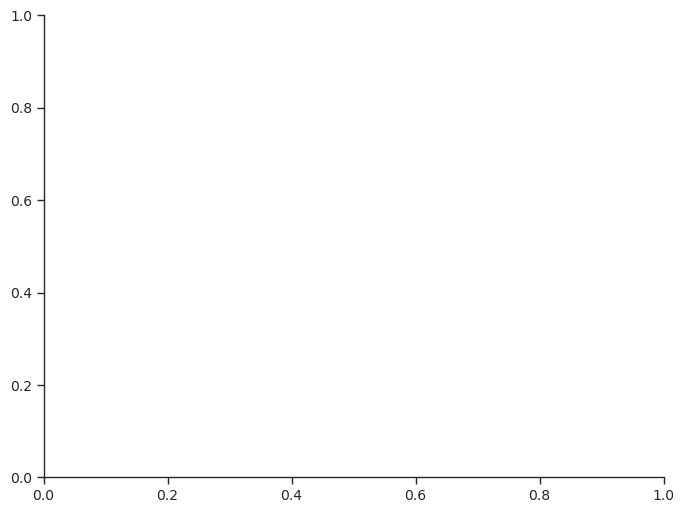

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
Script Name: MCMC Diagnostics, Quantitative PPC, and Robust Selection (Step 4)
Description: 
  - Upgraded to 'Standard Publication' tier based on Pan et al. recommendations.
  - Enforces the Two-Tier Convergence Funnel (Eligibility vs. Publication-Ready),
    now formally integrating MCSE (Monte Carlo Standard Error) limits.
  - Automatically exports Trace Diagnostics (Primary & Top 10 Worst R-hat).
  - Upgrades Posterior Predictive Checks (PPC) from qualitative plots to 
    quantitative adequacy metrics (MAE and Max Absolute Error thresholds).
  - Generates the Final Model Selection Audit combining Strict Diagnostics, 
    PPC Adequacy, and DIC rankings.
=============================================================================
"""

import os
import logging
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# SAFEGUARD: PERSISTENT CONFIGURATION IMPORT
# -----------------------------------------------------------------------------
try:
    from hddm_config import CFG
except ImportError:
    raise ImportError(
        "CRITICAL ERROR: 'hddm_config.py' not found on disk. "
        "Execute Step 2a to generate the global configuration."
    )

# =============================================================================
# DIRECTORY CONFIGURATION
# =============================================================================
INPUT_ROOT_NC = Path(f'bayesian_results_netcdf_{CFG.prior_type}_{CFG.hierarchy}')
INPUT_ROOT_MODELS = CFG.output_dir  
OUTPUT_ROOT = Path(f'bayesian_diagnostics_{CFG.prior_type}_{CFG.hierarchy}')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

ALL_MODELS = CFG.core_models + CFG.exploratory_models

# =============================================================================
# LOGGING SETUP
# =============================================================================
def setup_diagnostic_logger() -> logging.Logger:
    """Initializes standardized logging for diagnostic evaluations."""
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    logger = logging.getLogger(f'hddm_diagnostics_{ts}')
    logger.handlers = []
    logger.setLevel(logging.INFO)
    
    fmt = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%H:%M:%S')
    fh = logging.FileHandler(OUTPUT_ROOT / f'diagnostic_selection_report_{ts}.log', encoding='utf-8')
    ch = logging.StreamHandler()
    fh.setFormatter(fmt)
    ch.setFormatter(fmt)
    
    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger

# =============================================================================
# DIAGNOSTICS & SELECTION ENGINE
# =============================================================================
class BayesianDiagnosticsEngine:
    
    def __init__(self):
        self.logger = setup_diagnostic_logger()
        self.comparison_records: List[Dict] = []
        self.ppc_records: List[Dict] = []
        self.map_failures_df = self._load_map_failures()
        
        self.logger.info("=" * 80)
        self.logger.info("MCMC CONVERGENCE, QUANTITATIVE PPC & ROBUST MODEL SELECTION")
        self.logger.info(f"Target Hierarchy: {CFG.hierarchy.upper()}")
        self.logger.info(f"Strict Standard:  R-hat <= {CFG.rhat_strict}, ESS >= {CFG.ess_strict}")
        self.logger.info(f"PPC Max MAE:      Choice <= {CFG.ppc_choice_mae_max}, RT <= {CFG.ppc_rt_quantile_mae_max}")
        self.logger.info("=" * 80)

    def _load_map_failures(self) -> pd.DataFrame:
        """Loads MAP initialization failure logs."""
        map_log_path = INPUT_ROOT_MODELS / "map_initialization_report.csv"
        if map_log_path.exists():
            return pd.read_csv(map_log_path)
        return pd.DataFrame(columns=["Model", "Chain", "Seed", "MAP_Initialization_Failed"])

    def _get_map_failure_stats(self, model_flag: str) -> int:
        """Extracts absolute MAP failure counts."""
        if self.map_failures_df.empty: return 0
        model_fails = self.map_failures_df[self.map_failures_df['Model'] == model_flag]
        if model_fails.empty: return 0
        return int(model_fails['MAP_Initialization_Failed'].sum())

    def evaluate_convergence(self, idata: az.InferenceData, model_flag: str) -> Dict[str, Any]:
        """Calculates R-hat, ESS, and MCSE. Auto-plots traces."""
        self.logger.info(f"\nEvaluating MCMC convergence for [{model_flag}]...")
        
        summary_df = az.summary(idata, round_to=4)
        out_csv = OUTPUT_ROOT / f"diagnostics_summary_{model_flag}.csv"
        summary_df.to_csv(out_csv)
        
        # MCSE relative to posterior SD (commonly advised to be < 0.01 for strict, < 0.05 for eligible)
        summary_df['mcse_mean_ratio'] = summary_df['mcse_mean'] / summary_df['sd']
        
        max_rhat = float(summary_df['r_hat'].max())
        min_ess_bulk = float(summary_df['ess_bulk'].min())
        min_ess_tail = float(summary_df['ess_tail'].min())
        max_mcse_mean = float(summary_df['mcse_mean'].max())
        max_mcse_sd = float(summary_df['mcse_sd'].max())
        max_mcse_ratio = float(summary_df['mcse_mean_ratio'].max())
        
        self.logger.info(f"  -> Max R-hat: {max_rhat:.3f} | Min ESS Bulk: {min_ess_bulk:.1f} | Max MCSE Ratio: {max_mcse_ratio:.3f}")
        
        # Determine Pass Flags
        eligibility_pass = (max_rhat <= CFG.rhat_eligible) and (min_ess_bulk >= CFG.ess_eligible) and (min_ess_tail >= CFG.ess_eligible) and (max_mcse_ratio <= CFG.mcse_eligible)
        strict_pass = (max_rhat <= CFG.rhat_strict) and (min_ess_bulk >= CFG.ess_strict) and (min_ess_tail >= CFG.ess_strict) and (max_mcse_ratio <= CFG.mcse_strict)
        
        # Automated Trace Archiving
        self._export_trace_plots(idata, summary_df, model_flag)
        
        return {
            'max_rhat': max_rhat,
            'min_ess_bulk': min_ess_bulk,
            'min_ess_tail': min_ess_tail,
            'max_mcse_mean': max_mcse_mean,
            'max_mcse_sd': max_mcse_sd,
            'eligibility_pass': eligibility_pass,
            'strict_pass': strict_pass
        }

    def _export_trace_plots(self, idata: az.InferenceData, summary_df: pd.DataFrame, model_flag: str):
        """Generates and saves visual trace diagnostics automatically."""
        post_vars = list(idata.posterior.data_vars.keys())
        
        # 1. Primary Parameters Trace
        primary_vars = [v for v in post_vars if any(v.startswith(f"{p}_") for p in CFG.primary_parameters) and not v.endswith('_std')]
        if primary_vars:
            try:
                az.plot_trace(idata, var_names=primary_vars, compact=True, figsize=(12, 2.5 * len(primary_vars)))
                plt.tight_layout()
                plt.savefig(OUTPUT_ROOT / f"trace_primary_{model_flag}.pdf", dpi=150, bbox_inches='tight')
                plt.close()
            except Exception as e:
                self.logger.warning(f"  [Warning] Failed to plot primary trace for {model_flag}: {e}")
        
        # 2. Top 10 Worst R-hat Parameters Trace
        worst_vars = summary_df.nlargest(10, 'r_hat').index.tolist()
        worst_vars = [v.split('[')[0] for v in worst_vars] # Clean arviz indexing format
        worst_vars = list(dict.fromkeys(worst_vars))[:10]  # Unique base variables
        
        if worst_vars:
            try:
                az.plot_trace(idata, var_names=worst_vars, compact=True, figsize=(12, 2.5 * len(worst_vars)))
                plt.tight_layout()
                plt.savefig(OUTPUT_ROOT / f"trace_top10_worst_rhat_{model_flag}.pdf", dpi=150, bbox_inches='tight')
                plt.close()
            except Exception as e:
                self.logger.warning(f"  [Warning] Failed to plot worst R-hat trace for {model_flag}: {e}")

    def evaluate_quantitative_ppc(self, idata: az.InferenceData, model_flag: str) -> Dict[str, Any]:
        """Quantifies Posterior Predictive Adequacy into MAE and determines Pass/Fail."""
        self.logger.info(f"  Quantifying PPC Adequacy for [{model_flag}]...")
        
        if not hasattr(idata, 'posterior_predictive') or not hasattr(idata, 'observed_data'):
            self.logger.warning("  [!] PPC data missing in NetCDF.")
            return {'choice_pass': False, 'rt_pass': False, 'overall_pass': False}

        obs_df = pd.DataFrame({
            'emotion': idata.observed_data['emotion'].values,
            'response': idata.observed_data['response'].values,
            'rt': np.abs(idata.observed_data['rt'].values)
        })
        emotions = obs_df['emotion'].unique()
        
        sim_resp = idata.posterior_predictive['response'].values.astype(np.float32)
        sim_rt = np.abs(idata.posterior_predictive['rt'].values)
        n_chains, n_draws, n_trials = sim_resp.shape
        sim_resp_flat = sim_resp.reshape(n_chains * n_draws, n_trials)
        sim_rt_flat = sim_rt.reshape(n_chains * n_draws, n_trials)

        # 1. Choice PPC Evaluation (Rejection Rates)
        obs_reject = 1.0 - obs_df.groupby('emotion')['response'].mean()
        choice_errors = []
        for emo in emotions:
            idx = obs_df['emotion'] == emo
            sim_reject_mean = (1.0 - sim_resp_flat[:, idx].mean(axis=1)).mean()
            choice_errors.append(np.abs(obs_reject[emo] - sim_reject_mean))
        
        choice_mae = np.mean(choice_errors)
        choice_max_err = np.max(choice_errors)
        choice_pass = (choice_mae <= CFG.ppc_choice_mae_max) and (choice_max_err <= CFG.ppc_choice_max_err)

        # 2. RT Quantile PPC Evaluation
        quantiles = [0.1, 0.3, 0.5, 0.7, 0.9]
        rt_errors = []
        for emo in emotions:
            idx = obs_df['emotion'] == emo
            obs_q = np.quantile(obs_df.loc[idx, 'rt'], quantiles)
            # Compute quantiles for each simulated draw, then average
            sim_q_draws = np.quantile(sim_rt_flat[:, idx], quantiles, axis=1) 
            sim_q_mean = sim_q_draws.mean(axis=1) # shape (5,)
            rt_errors.extend(np.abs(obs_q - sim_q_mean))
            
        rt_mae = np.mean(rt_errors)
        rt_max_err = np.max(rt_errors)
        rt_pass = (rt_mae <= CFG.ppc_rt_quantile_mae_max) and (rt_max_err <= CFG.ppc_rt_quantile_max_err)

        overall_pass = choice_pass and rt_pass
        
        self.logger.info(f"  -> PPC Choice MAE: {choice_mae:.3f} | PPC RT MAE: {rt_mae:.3f} | Adequacy Pass: {overall_pass}")

        ppc_res = {
            'Model': model_flag,
            'Choice_MAE': choice_mae,
            'Choice_MaxErr': choice_max_err,
            'RT_MAE': rt_mae,
            'RT_MaxErr': rt_max_err,
            'PPC_Choice_Pass': choice_pass,
            'PPC_RT_Pass': rt_pass,
            'PPC_Overall_Pass': overall_pass
        }
        self.ppc_records.append(ppc_res)
        return ppc_res

    def process_all_models(self):
        """Iterates through NetCDFs to compile criteria."""
        if not INPUT_ROOT_NC.exists():
            self.logger.error(f"Critical Path Error: NetCDF directory missing.")
            return
            
        for model_flag in ALL_MODELS:
            nc_file = INPUT_ROOT_NC / (f"{model_flag}_model_arviz.nc" if model_flag == 'null' else f"{model_flag}_emotion_arviz.nc")
            if not nc_file.exists(): continue
                
            try:
                idata = az.from_netcdf(str(nc_file))
                dic_val = idata.posterior.attrs.get('dic_score', np.nan)
                
                # Diagnostics & PPC
                diag_stats = self.evaluate_convergence(idata, model_flag)
                ppc_stats = self.evaluate_quantitative_ppc(idata, model_flag)
                map_fails = self._get_map_failure_stats(model_flag)
                
                category = "Core" if model_flag in CFG.core_models else "Exploratory"
                
                self.comparison_records.append({
                    "Model": model_flag,
                    "Category": category,
                    "DIC": dic_val,
                    "Max_R_hat": diag_stats['max_rhat'],
                    "Min_ESS_Bulk": diag_stats['min_ess_bulk'],
                    "Max_MCSE_Mean": diag_stats['max_mcse_mean'],
                    "MAP_Failures": map_fails,
                    "Eligibility_Pass": diag_stats['eligibility_pass'],
                    "Strict_Pass": diag_stats['strict_pass'],
                    "PPC_Choice_Pass": ppc_stats['PPC_Choice_Pass'],
                    "PPC_RT_Pass": ppc_stats['PPC_RT_Pass'],
                    "PPC_Overall_Pass": ppc_stats['PPC_Overall_Pass']
                })
                
                del idata
                
            except Exception as e:
                self.logger.error(f"Error processing {model_flag}: {e}")
                
        self._enforce_publication_selection()

    def _enforce_publication_selection(self):
        """
        Executes the Pan et al. Logic:
        Strict_Pass -> PPC_Overall_Pass -> Lowest DIC.
        Generates the final audit trail.
        """
        if not self.comparison_records:
            self.logger.error("No diagnostic records generated. Pipeline aborted.")
            return
            
        df_comp = pd.DataFrame(self.comparison_records)
        
        # Save raw PPC summary
        pd.DataFrame(self.ppc_records).to_csv(OUTPUT_ROOT / "ppc_adequacy_summary.csv", index=False)
        
        # Sort logic: Strict(True>False), PPC(True>False), Eligible(True>False), DIC(Ascending)
        df_comp = df_comp.sort_values(
            by=["Strict_Pass", "PPC_Overall_Pass", "Eligibility_Pass", "DIC"], 
            ascending=[False, False, False, True]
        ).reset_index(drop=True)
        
        # Determine Rationale and Fallbacks for Audit
        audit_records = []
        best_model_found = False
        
        for idx, row in df_comp.iterrows():
            fallback = "No"
            if row['Strict_Pass'] and row['PPC_Overall_Pass']:
                rationale = "Strict Convergence + PPC Passed + Lowest DIC"
            elif row['Strict_Pass'] and not row['PPC_Overall_Pass']:
                rationale = "Strict Convergence + Lowest DIC (PPC Failed)"
                fallback = "Yes (PPC Adequacy Compromised)"
            elif row['Eligibility_Pass'] and row['PPC_Overall_Pass']:
                rationale = "Eligible Convergence + PPC Passed + Lowest DIC"
                fallback = "Yes (Failed Strict Convergence)"
            elif row['Eligibility_Pass']:
                rationale = "Eligible Convergence + Lowest DIC"
                fallback = "Yes (Failed Strict & PPC)"
            else:
                rationale = "Rejected: Failed minimum convergence eligibility"
                fallback = "N/A"
            
            # The top row that is at least eligible becomes the Selection_Primary
            is_selected = False
            if not best_model_found and row['Eligibility_Pass']:
                is_selected = True
                best_model_found = True
                
            audit_records.append({
                "Model": row['Model'],
                "Selected_As_Best": is_selected,
                "Selection_Rationale": rationale,
                "Fallback_Used": fallback,
                "DIC": row['DIC'],
                "Eligibility_Pass": row['Eligibility_Pass'],
                "Strict_Pass": row['Strict_Pass'],
                "PPC_Overall_Pass": row['PPC_Overall_Pass']
            })

        df_audit = pd.DataFrame(audit_records)
        df_audit.to_csv(OUTPUT_ROOT / "final_model_selection_audit.csv", index=False)
        df_comp.to_csv(OUTPUT_ROOT / "diagnostics_full_consensus.csv", index=False)
        
        self.logger.info("\n" + "=" * 105)
        self.logger.info("FINAL PUBLICATION-READY MODEL SELECTION AUDIT")
        self.logger.info("=" * 105)
        
        for _, row in df_audit.iterrows():
            sel_str = ">>> SELECTED <<<" if row['Selected_As_Best'] else ""
            self.logger.info(f"Model: {row['Model']:<6} | DIC: {row['DIC']:<7.1f} | Strict: {str(row['Strict_Pass']):<5} | PPC: {str(row['PPC_Overall_Pass']):<5} | {sel_str}")
            self.logger.info(f"   Rationale: {row['Selection_Rationale']}")
            self.logger.info(f"   Fallback:  {row['Fallback_Used']}\n")
            
        if not best_model_found:
            raise RuntimeError("CRITICAL: No models passed the minimum Eligibility threshold. Do not proceed to interpretation.")

# =============================================================================
# PIPELINE EXECUTION
# =============================================================================
if __name__ == "__main__":
    engine = BayesianDiagnosticsEngine()
    engine.process_all_models()

# Step 5: Statistical Inference and Publication-Ready Visualization

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
Script Name: Posterior Inference and Publication Visualization (Step 5)
Description: 
  - Upgraded to 'Standard Publication' tier based on Pan et al.
  - Strictly enforces the Convergence Funnel by reading the Step 4 Audit.
  - Reconstructs marginal posteriors in physical scales (handling link functions).
  - Computes Direct Posterior Contrasts between all emotion conditions.
  - Integrates 'Primary' vs 'Exploratory' Parameter Interpretation Levels.
  - Implements publication-ready PPC visualizations (Choice & RT Quantiles).
  - FIX: Resolved previous Context Manager (AttributeError: __enter__) bug 
    when loading ArviZ InferenceData.
=============================================================================
"""

import os
import re
import logging
import itertools
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

# -----------------------------------------------------------------------------
# SAFEGUARD: PERSISTENT CONFIGURATION IMPORT
# -----------------------------------------------------------------------------
try:
    from hddm_config import CFG
except ImportError:
    raise ImportError(
        "CRITICAL ERROR: 'hddm_config.py' not found on disk. "
        "Execute Step 2a to generate the global configuration."
    )

# =============================================================================
# DIRECTORY & AESTHETIC CONFIGURATION
# =============================================================================
INPUT_ROOT_NC = Path(f'bayesian_results_netcdf_{CFG.prior_type}_{CFG.hierarchy}')
INPUT_ROOT_DIAG = Path(f'bayesian_diagnostics_{CFG.prior_type}_{CFG.hierarchy}')
OUTPUT_ROOT = Path(f'publication_figures_{CFG.prior_type}_{CFG.hierarchy}')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Publication-ready visualization aesthetics (APA / Nature Standards)
sns.set_theme(style="ticks", palette="colorblind")
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# =============================================================================
# LOGGING SETUP
# =============================================================================
def setup_publication_logger() -> logging.Logger:
    """Initializes standardized logging for the reconstruction engine."""
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    logger = logging.getLogger(f'hddm_publication_{ts}')
    logger.handlers = []
    logger.setLevel(logging.INFO)
    
    fmt = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%H:%M:%S')
    fh = logging.FileHandler(OUTPUT_ROOT / f'reconstruction_inference_{ts}.log', encoding='utf-8')
    ch = logging.StreamHandler()
    fh.setFormatter(fmt)
    ch.setFormatter(fmt)
    
    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger

# =============================================================================
# RECONSTRUCTION & VISUALIZATION ENGINE
# =============================================================================
class PublicationEngine:
    """Manages parameter transformation, rigorous contrasts, and academic plotting."""
    
    def __init__(self):
        self.logger = setup_publication_logger()
        self.best_model_name: str = ""
        self.idata: Optional[az.InferenceData] = None
        
        # Structure: {parameter: {condition: numpy_array_of_samples}}
        self.marginals: Dict[str, Dict[str, np.ndarray]] = {p: {} for p in ['v', 'a', 't', 'z']}
        
        self.logger.info("=" * 80)
        self.logger.info("POSTERIOR RECONSTRUCTION, CONTRASTS & VISUALIZATION PIPELINE")
        self.logger.info("=" * 80)

    def _apply_link_function(self, param: str, linear_predictor: np.ndarray) -> np.ndarray:
        """
        Maps hierarchical regression coefficients back to physiological scales.
        Drift (v): Identity Link
        Boundary (a), Non-decision (t): Log Link -> Exponential Transform
        Starting Point (z): Logit Link -> Expit Transform
        """
        if param == 'v':
            return linear_predictor
        elif param in ['a', 't']:
            return np.exp(linear_predictor)
        elif param == 'z':
            return expit(linear_predictor)
        else:
            raise ValueError(f"Link function undefined for parameter: {param}")

    def identify_optimal_model(self) -> str:
        """STRICT GATEKEEPER: Reads Step 4 Final Audit. Halts if no model was selected."""
        audit_csv = INPUT_ROOT_DIAG / "final_model_selection_audit.csv"
        if not audit_csv.exists():
            raise FileNotFoundError(f"Missing selection audit at {audit_csv}. Run Step 4.")
            
        df = pd.read_csv(audit_csv)
        selected_df = df[df['Selected_As_Best'] == True]
        
        if selected_df.empty:
            error_msg = "CRITICAL FAILURE: No model was marked as 'Selected_As_Best' in Step 4. Stop posterior reconstruction."
            self.logger.error(error_msg)
            raise RuntimeError(error_msg)
            
        best_model = selected_df.iloc[0]['Model']
        self.logger.info(f"Gatekeeper passed. Target optimal model: [{best_model}]")
        self.logger.info(f"Selection Rationale: {selected_df.iloc[0]['Selection_Rationale']}")
        return best_model

    def load_and_reconstruct(self, model_flag: str):
        """Extracts absolute parameter distributions operating in linear predictor space."""
        nc_name = f"{model_flag}_model_arviz.nc" if model_flag == 'null' else f"{model_flag}_emotion_arviz.nc"
        nc_path = INPUT_ROOT_NC / nc_name
        
        if not nc_path.exists():
            raise FileNotFoundError(f"InferenceData not found at {nc_path}")
            
        self.logger.info(f"Loading MCMC posterior arrays from {nc_name}...")
        
        # FIX: Removed the 'with' context manager to prevent AttributeError: __enter__
        self.idata = az.from_netcdf(str(nc_path))
        self.best_model_name = model_flag
        
        post_vars = list(self.idata.posterior.data_vars.keys())
        
        for param in ['v', 'a', 't', 'z']:
            intercept_key = f"{param}_Intercept"
            if intercept_key not in post_vars:
                continue
                
            self.logger.info(f"  Reconstructing marginals for [{param}]...")
            base_lp = self.idata.posterior[intercept_key].values.flatten()
            self.marginals[param][CFG.baseline_condition] = self._apply_link_function(param, base_lp)
            
            pattern = re.compile(rf"{param}_C\(emotion, Treatment\(\"{CFG.baseline_condition}\"\)\)\[T\.([^\]]+)\]")
            delta_keys = [v for v in post_vars if pattern.match(v)]
            
            for dk in delta_keys:
                cond = pattern.search(dk).group(1)
                diff_lp = self.idata.posterior[dk].values.flatten()
                
                # Addition occurs strictly in the unbounded linear predictor space
                combined_lp = base_lp + diff_lp 
                self.marginals[param][cond] = self._apply_link_function(param, combined_lp)

    def export_ground_truth_and_summary(self):
        """Exports fully reconstructed physical marginals with Interpretation Levels."""
        export_data = []
        for param, conditions in self.marginals.items():
            if not conditions: 
                continue
                
            interpretation = "Primary" if param in CFG.primary_parameters else "Exploratory"
                
            for cond, samples in conditions.items():
                hdi_3, hdi_97 = np.percentile(samples, [2.5, 97.5])
                export_data.append({
                    'Parameter': param,
                    'Interpretation_Level': interpretation,
                    'Condition': cond,
                    'Posterior_Mean': np.mean(samples),
                    'Posterior_Median': np.median(samples),
                    'Posterior_SD': np.std(samples),
                    'HDI_2.5': hdi_3,
                    'HDI_97.5': hdi_97
                })
        
        df_gt = pd.DataFrame(export_data)
        out_csv = OUTPUT_ROOT / f"parameter_summary_{self.best_model_name}.csv"
        df_gt.to_csv(out_csv, index=False)
        self.logger.info(f"Exported parameter summary to {out_csv.name}")

    def compute_direct_contrasts(self):
        """Computes direct Bayesian contrasts between all emotion conditions."""
        self.logger.info("Computing Direct Posterior Contrasts...")
        contrasts = []
        
        for param, conditions in self.marginals.items():
            if not conditions:
                continue
            
            cond_names = list(conditions.keys())
            interpretation = "Primary" if param in CFG.primary_parameters else "Exploratory"
            
            for cond1, cond2 in itertools.combinations(cond_names, 2):
                diff = conditions[cond1] - conditions[cond2]
                
                p_greater = (diff > 0).mean()
                hdi_3, hdi_97 = np.percentile(diff, [2.5, 97.5])
                
                # Assign Evidence Label based on posterior probability
                prob_max = max(p_greater, 1.0 - p_greater)
                if prob_max > 0.99: evidence = "Strong"
                elif prob_max > 0.95: evidence = "Moderate"
                else: evidence = "Uncertain"

                contrasts.append({
                    'Parameter': param,
                    'Interpretation_Level': interpretation,
                    'Contrast': f"{cond1} > {cond2}",
                    'Diff_Mean': np.mean(diff),
                    'HDI_2.5': hdi_3,
                    'HDI_97.5': hdi_97,
                    'P(diff > 0)': p_greater,
                    'Evidence': evidence
                })
                
                # Symmetrical contrast
                contrasts.append({
                    'Parameter': param,
                    'Interpretation_Level': interpretation,
                    'Contrast': f"{cond2} > {cond1}",
                    'Diff_Mean': np.mean(-diff),
                    'HDI_2.5': -hdi_97,
                    'HDI_97.5': -hdi_3,
                    'P(diff > 0)': 1.0 - p_greater,
                    'Evidence': evidence
                })
                
        df_contrasts = pd.DataFrame(contrasts)
        out_csv = OUTPUT_ROOT / f"posterior_direct_contrasts_{self.best_model_name}.csv"
        df_contrasts.to_csv(out_csv, index=False)
        self.logger.info(f"Exported Direct Contrasts to {out_csv.name}")

    def plot_parameter_posteriors(self):
        """Generates publication-ready density distributions, tagging Exploratory params."""
        self.logger.info("Rendering parameter posterior distributions...")
        
        for param, conditions in self.marginals.items():
            if not conditions:
                continue
                
            interpretation = "Primary" if param in CFG.primary_parameters else "Exploratory"
                
            plot_df = []
            for cond, samples in conditions.items():
                temp_df = pd.DataFrame({'Condition': cond, 'Value': samples})
                plot_df.append(temp_df)
            plot_df = pd.concat(plot_df, ignore_index=True)
            
            fig, ax = plt.subplots(figsize=(7, 4.5))
            sns.violinplot(
                data=plot_df, x='Condition', y='Value', 
                inner='quartile', linewidth=1.5, alpha=0.8, color='#B0BEC5', ax=ax
            )
            
            ax.set_title(f"Posterior Distribution: {param.upper()} ({interpretation})", pad=15)
            ax.set_ylabel("Parameter Value (Physical Scale)")
            ax.set_xlabel("Emotion Condition")
            
            plt.tight_layout()
            out_pdf = OUTPUT_ROOT / f"posterior_{param}_{interpretation.lower()}_{self.best_model_name}.pdf"
            plt.savefig(out_pdf, dpi=300)
            plt.close()

    def plot_rejection_probability_ppc(self):
        """Generates Rejection Rate Posterior Predictive Checks."""
        self.logger.info("Rendering Emotion-Specific Rejection Probability PPC...")
        if not hasattr(self.idata, 'posterior_predictive') or not hasattr(self.idata, 'observed_data'):
            self.logger.warning("PPC modules absent. Skipping Rejection plot.")
            return

        obs_resp = self.idata.observed_data['response'].values
        obs_emo = self.idata.observed_data['emotion'].values
        df_obs = pd.DataFrame({'emotion': obs_emo, 'response': obs_resp})
        
        obs_reject_rates = 1.0 - df_obs.groupby('emotion')['response'].mean()

        sim_resp = self.idata.posterior_predictive['response'].values.astype(np.float32)
        n_chains, n_draws, n_trials = sim_resp.shape
        sim_resp_flat = sim_resp.reshape(n_chains * n_draws, n_trials)
        
        sim_rates_list = []
        for emo in df_obs['emotion'].unique():
            idx = df_obs['emotion'] == emo
            sim_reject_rates = 1.0 - sim_resp_flat[:, idx].mean(axis=1)
            temp_df = pd.DataFrame({'emotion': emo, 'Simulated_Rejection_Rate': sim_reject_rates})
            sim_rates_list.append(temp_df)
            
        df_sim = pd.concat(sim_rates_list, ignore_index=True)

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.violinplot(
            data=df_sim, x='emotion', y='Simulated_Rejection_Rate', 
            inner='quartile', color='#E0E0E0', linewidth=1.2, ax=ax
        )
        
        sns.scatterplot(
            x=obs_reject_rates.index, y=obs_reject_rates.values, 
            color='#900C3F', s=150, marker='D', label='Empirical Rejection Rate', 
            zorder=5, edgecolor='black', ax=ax
        )
        
        ax.set_title("PPC: Emotion-Driven Rejection Probability", pad=15)
        ax.set_ylabel("Probability of Rejection")
        ax.set_xlabel("Emotion Condition")
        
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.savefig(OUTPUT_ROOT / f"ppc_choice_rejection_prob_{self.best_model_name}.pdf", dpi=300)
        plt.close()

    def plot_rt_quantile_ppc(self):
        """Generates RT Quantile Posterior Predictive Checks."""
        self.logger.info("Computing and Rendering RT Quantile PPC...")
        if not hasattr(self.idata, 'posterior_predictive') or not hasattr(self.idata, 'observed_data'):
            return

        obs_rt = np.abs(self.idata.observed_data['rt'].values) # Ensure absolute RTs
        obs_emo = self.idata.observed_data['emotion'].values
        df_obs = pd.DataFrame({'emotion': obs_emo, 'rt': obs_rt})
        
        quantiles = [0.1, 0.3, 0.5, 0.7, 0.9]
        obs_q = df_obs.groupby('emotion')['rt'].quantile(quantiles).unstack()

        sim_rt = np.abs(self.idata.posterior_predictive['rt'].values)
        n_chains, n_draws, n_trials = sim_rt.shape
        
        ppc_rt_records = []
        
        for emo in df_obs['emotion'].unique():
            idx = df_obs['emotion'] == emo
            emo_sim_rt = sim_rt[:, :, idx] 
            
            # Calculate quantiles per draw to get distribution of quantiles
            for c in range(n_chains):
                for d in range(n_draws):
                    draw_rt = emo_sim_rt[c, d, :]
                    q_vals = np.quantile(draw_rt, quantiles)
                    for q, val in zip(quantiles, q_vals):
                        ppc_rt_records.append({'emotion': emo, 'quantile': q, 'sim_rt': val})
                        
        df_sim_rt = pd.DataFrame(ppc_rt_records)
        
        # Plotting
        emotions = df_obs['emotion'].unique()
        fig, axes = plt.subplots(1, len(emotions), figsize=(3 * len(emotions), 4), sharey=True)
        if len(emotions) == 1: axes = [axes]
        
        for ax, emo in zip(axes, emotions):
            sns.pointplot(
                data=df_sim_rt[df_sim_rt['emotion'] == emo], 
                x='quantile', y='sim_rt', errorbar=('pi', 95), 
                color='#B0BEC5', join=False, capsize=0.1, ax=ax, label='95% HDI (Simulated)'
            )
            ax.plot(
                range(len(quantiles)), obs_q.loc[emo].values, 
                color='#900C3F', marker='D', linestyle='', markersize=8, label='Empirical RT'
            )
            ax.set_title(f"Emotion: {emo.upper()}", pad=10)
            ax.set_xlabel("Quantile")
            if ax == axes[0]:
                ax.set_ylabel("Reaction Time (s)")
            else:
                ax.set_ylabel("")
                
        # Add legend to the last plot
        axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.suptitle("PPC: Reaction Time Quantiles (10%, 30%, 50%, 70%, 90%)", y=1.05, fontweight='bold')
        plt.tight_layout()
        plt.savefig(OUTPUT_ROOT / f"ppc_rt_quantiles_{self.best_model_name}.pdf", dpi=300, bbox_inches='tight')
        plt.close()

    def run_pipeline(self):
        """Orchestrates visualization and extraction sequence."""
        best_model = self.identify_optimal_model()
        self.load_and_reconstruct(best_model)
        
        self.export_ground_truth_and_summary()
        self.compute_direct_contrasts()
        
        self.plot_parameter_posteriors()
        self.plot_rejection_probability_ppc()
        self.plot_rt_quantile_ppc()
        
        if self.idata is not None:
            del self.idata
            
        self.logger.info("\n" + "=" * 80)
        self.logger.info("PUBLICATION VISUALIZATION COMPLETED SUCCESSFULLY")
        self.logger.info("=" * 80)

# =============================================================================
# PIPELINE EXECUTION
# =============================================================================
if __name__ == "__main__":
    engine = PublicationEngine()
    engine.run_pipeline()

09:41:38 - ======================================================================
09:41:38 - PUBLICATION DATA INGESTION & RECONSTRUCTION
09:41:38 - ======================================================================
09:41:38 - Identified optimal model via DIC: v_emotion_inf_full
09:41:38 - Total valid models in theoretical space: 2
09:41:40 - Reconstructing marginal posterior matrices...
09:41:40 - Compiling Multiverse representation for parameter 'z'...


AttributeError: __enter__

# Step 6: Data Informed Group-Level Parameter Recovery

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
Script Name: Data-Informed Group-Level Recovery and Identifiability (Step 6)
Description: 
  - Upgraded to 'Standard Publication' tier.
  - Dynamically loads empirical ground truth parameters exported from Step 5,
    strictly governed by the Step 4 final selection audit.
  - Generates a synthetic cohort applying inter-subject variability exclusively 
    within the unconstrained latent space (Log/Logit) using Config SDs.
  - Fits a recovery MCMC model with strictly safe memory settings 
    (keep_regressor_trace=False) matching Step 2b.
  - Computes comprehensive identifiability metrics: HDI Coverage, Pearson r, 
    Bias, and Root Mean Square Error (RMSE).
=============================================================================
"""

import os
import gc
import logging
from pathlib import Path
from datetime import datetime
from typing import Dict, List

import numpy as np
import pandas as pd
import hddm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logit, expit

# -----------------------------------------------------------------------------
# SAFEGUARD: PERSISTENT CONFIGURATION IMPORT
# -----------------------------------------------------------------------------
try:
    from hddm_config import CFG
except ImportError:
    raise ImportError(
        "CRITICAL ERROR: 'hddm_config.py' not found on disk. "
        "Execute Step 2a to generate the global configuration."
    )

# =============================================================================
# DIRECTORY & AESTHETIC CONFIGURATION
# =============================================================================
INPUT_ROOT_DIAG = Path(f'bayesian_diagnostics_{CFG.prior_type}_{CFG.hierarchy}')
INPUT_ROOT_PUB = Path(f'publication_figures_{CFG.prior_type}_{CFG.hierarchy}')
OUTPUT_ROOT = Path(f'parameter_recovery_{CFG.prior_type}_{CFG.hierarchy}')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Publication-ready visualization aesthetics
sns.set_theme(style="ticks", palette="colorblind")
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# =============================================================================
# LOGGING SETUP
# =============================================================================
def setup_recovery_logger() -> logging.Logger:
    """Initializes standardized logging for parameter recovery metrics."""
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    logger = logging.getLogger(f'hddm_recovery_{ts}')
    logger.handlers = []
    logger.setLevel(logging.INFO)
    
    fmt = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%H:%M:%S')
    fh = logging.FileHandler(OUTPUT_ROOT / f'data_informed_recovery_{ts}.log', encoding='utf-8')
    ch = logging.StreamHandler()
    fh.setFormatter(fmt)
    ch.setFormatter(fmt)
    
    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger

# =============================================================================
# PARAMETER RECOVERY ENGINE
# =============================================================================
class ParameterRecoveryEngine:
    
    def __init__(self):
        self.logger = setup_recovery_logger()
        self.ground_truth_df: pd.DataFrame = pd.DataFrame()
        self.synthetic_data: pd.DataFrame = pd.DataFrame()
        self.best_model_name: str = ""
        self.recovery_stats: List[Dict] = []
        
        # Enforces absolute reproducibility for synthetic cohort generation
        np.random.seed(CFG.base_seed)
        
        self.logger.info("=" * 80)
        self.logger.info("DATA-INFORMED GROUP-LEVEL RECOVERY & IDENTIFIABILITY PIPELINE")
        self.logger.info(f"Target Hierarchy: {CFG.hierarchy.upper()} | Run Mode: {CFG.run_mode.upper()}")
        self.logger.info("=" * 80)

    def load_ground_truth(self) -> bool:
        """Determines the correct model from Step 4 audit and loads Step 5 ground truth."""
        audit_csv = INPUT_ROOT_DIAG / "final_model_selection_audit.csv"
        if not audit_csv.exists():
            self.logger.error(f"Missing selection audit at {audit_csv}. Run Step 4.")
            return False
            
        df_audit = pd.read_csv(audit_csv)
        selected_df = df_audit[df_audit['Selected_As_Best'] == True]
        
        if selected_df.empty:
            self.logger.error("No selected model found in audit file. Aborting recovery.")
            return False
            
        self.best_model_name = selected_df.iloc[0]['Model']
        self.logger.info(f"Targeting recovered model: [{self.best_model_name}]")
        
        gt_csv = INPUT_ROOT_PUB / f"parameter_summary_{self.best_model_name}.csv"
        if not gt_csv.exists():
            self.logger.error(f"Ground truth file missing: {gt_csv}. Run Step 5 first.")
            return False
            
        self.ground_truth_df = pd.read_csv(gt_csv)
        self.logger.info("Successfully loaded empirically informed ground truth matrix.")
        return True

    def generate_synthetic_cohort(self, n_subjects: int = 30, trials_per_cond: int = 100):
        """
        Generates behavioral distributions utilizing ground truth parameters.
        Injects variance in the unbounded latent space using configurations.
        """
        self.logger.info(f"Generating synthetic cohort (N={n_subjects}, Trials/Cond={trials_per_cond})...")
        synthetic_trials = []
        
        conditions = self.ground_truth_df['Condition'].unique()
        
        for subj_idx in range(n_subjects):
            for cond in conditions:
                cond_params = self.ground_truth_df[self.ground_truth_df['Condition'] == cond]
                
                # Extract empirical means. Fallbacks maintain generative stability.
                v_true = cond_params.loc[cond_params['Parameter'] == 'v', 'Posterior_Mean'].values
                a_true = cond_params.loc[cond_params['Parameter'] == 'a', 'Posterior_Mean'].values
                t_true = cond_params.loc[cond_params['Parameter'] == 't', 'Posterior_Mean'].values
                z_true = cond_params.loc[cond_params['Parameter'] == 'z', 'Posterior_Mean'].values
                
                v_val = float(v_true[0]) if len(v_true) > 0 else 0.5
                a_val = float(a_true[0]) if len(a_true) > 0 else 1.5
                t_val = float(t_true[0]) if len(t_true) > 0 else 0.3
                z_val = float(z_true[0]) if len(z_true) > 0 else 0.5
                
                # Transform to unconstrained latent space
                v_link = v_val
                a_link = np.log(a_val)
                t_link = np.log(t_val)
                z_link = logit(np.clip(z_val, 0.01, 0.99))
                
                # Inject inter-subject variability using Configured SDs
                v_subj_link = v_link + np.random.normal(0, CFG.recovery_sd_link_v)
                a_subj_link = a_link + np.random.normal(0, CFG.recovery_sd_link_a)
                t_subj_link = t_link + np.random.normal(0, CFG.recovery_sd_link_t)
                z_subj_link = z_link + np.random.normal(0, CFG.recovery_sd_link_z)
                
                # Transform back to physical space via inverse link functions
                sim_params = {
                    'v': v_subj_link,
                    'a': np.exp(a_subj_link),
                    't': np.exp(t_subj_link),
                    'z': expit(z_subj_link)
                }
                
                # Utilize HDDM internal generator for standardized DDM sampling
                sim_data, _ = hddm.generate.gen_rand_data({'wfpt': sim_params}, size=trials_per_cond)
                
                df_cond = pd.DataFrame(sim_data)
                df_cond['subj_idx'] = subj_idx
                df_cond['emotion'] = cond
                synthetic_trials.append(df_cond)
                
        self.synthetic_data = pd.concat(synthetic_trials, ignore_index=True)
        self.logger.info(f"Synthetic generation complete. Total simulated trials: {len(self.synthetic_data)}")

    def _build_recovery_formula(self) -> List[str]:
        """Constructs the exact regression matrix used in the target model."""
        ref = f'C(emotion, Treatment("{CFG.baseline_condition}"))'
        base_model = self.best_model_name.split("_")[0] 
        
        formulas = {
            'null': ['v~1', 'a~1', 't~1', 'z~1'],
            'v':    [f'v~{ref}', 'a~1', 't~1', 'z~1'],
            'a':    ['v~1', f'a~{ref}', 't~1', 'z~1'],
            'va':   [f'v~{ref}', f'a~{ref}', 't~1', 'z~1'],
            'vz':   [f'v~{ref}', 'a~1', 't~1', f'z~{ref}'],
            'vt':   [f'v~{ref}', 'a~1', f't~{ref}', 'z~1']
        }
        return formulas.get(base_model, formulas['va'])

    def fit_recovery_model(self):
        """Fits the synthetic data utilizing identically structured priors and safe memory bounds."""
        self.logger.info("Initiating parameter recovery MCMC estimation...")
        
        formulas = self._build_recovery_formula()
        
        # PUBLICATION STANDARD: keep_regressor_trace=False is strictly enforced here
        # to ensure the recovery fitting process does not cause Out-Of-Memory errors.
        model = hddm.HDDMRegressor(
            self.synthetic_data, formulas, include=['v', 'a', 't', 'z'],
            is_group_model=True, keep_regressor_trace=False, p_outlier=CFG.p_outlier,
            informative=CFG.use_informative_priors
        )
        
        try:
            model.find_starting_values()
        except Exception:
            self.logger.warning("MAP optimization failed for recovery. Falling back to priors.")
            
        db_path = str(OUTPUT_ROOT / f'recovery_{self.best_model_name}.db')
        model.sample(CFG.n_samples, burn=CFG.n_burn, thin=CFG.thin, dbname=db_path, db='pickle')
        
        self._evaluate_posterior(model)
        
        try: 
            model.db.close()
        except Exception: 
            pass
        del model
        gc.collect()

    def _evaluate_posterior(self, model: hddm.HDDMRegressor):
        """Calculates identical link functions and cross-references HDI boundaries."""
        traces = model.get_traces()
        
        for _, row in self.ground_truth_df.iterrows():
            param = row['Parameter']
            cond = row['Condition']
            interpretation = row['Interpretation_Level']
            true_val = float(row['Posterior_Mean'])
            
            intercept_key = f"{param}_Intercept"
            if intercept_key not in traces.columns:
                continue
                
            base_lp = traces[intercept_key].values
            
            if cond == CFG.baseline_condition:
                combined_lp = base_lp
            else:
                delta_key = f"{param}_C(emotion, Treatment(\"{CFG.baseline_condition}\"))[T.{cond}]"
                if delta_key in traces.columns:
                    combined_lp = base_lp + traces[delta_key].values
                else:
                    combined_lp = base_lp
            
            # Reconstruct physiological scales for accuracy evaluation
            if param == 'v':
                recovered_array = combined_lp
            elif param in ['a', 't']:
                recovered_array = np.exp(combined_lp)
            elif param == 'z':
                recovered_array = expit(combined_lp)
            else:
                continue
            
            hdi_lower, hdi_upper = np.percentile(recovered_array, [2.5, 97.5])
            recovered_mean = float(np.mean(recovered_array))
            
            is_covered = (true_val >= hdi_lower) and (true_val <= hdi_upper)
            bias = recovered_mean - true_val
            
            self.recovery_stats.append({
                'Parameter': param,
                'Interpretation_Level': interpretation,
                'Condition': cond,
                'True_Value': true_val,
                'Recovered_Mean': recovered_mean,
                'HDI_2.5': hdi_lower,
                'HDI_97.5': hdi_upper,
                'Covered_by_HDI': is_covered,
                'Bias': bias,
                'Squared_Error': bias ** 2
            })

    def evaluate_and_plot(self):
        """Compiles standard recovery metrics and generates academic visualizations."""
        if not self.recovery_stats:
            self.logger.error("No valid recovery statistics generated.")
            return
            
        df_rec = pd.DataFrame(self.recovery_stats)
        out_csv = OUTPUT_ROOT / f"data_informed_recovery_diagnostics_{self.best_model_name}.csv"
        df_rec.to_csv(out_csv, index=False)
        
        # ---------------------------------------------------------------------
        # METRICS COMPUTATION (Identifiability Report)
        # ---------------------------------------------------------------------
        coverage_rate = df_rec['Covered_by_HDI'].mean() * 100
        pearson_r = df_rec['True_Value'].corr(df_rec['Recovered_Mean'])
        global_bias = df_rec['Bias'].mean()
        global_rmse = np.sqrt(df_rec['Squared_Error'].mean())
        
        self.logger.info("\n" + "-" * 60)
        self.logger.info("DATA-INFORMED GROUP-LEVEL RECOVERY METRICS")
        self.logger.info("-" * 60)
        self.logger.info(f"  HDI Coverage (95%): {coverage_rate:.1f}%")
        self.logger.info(f"  Pearson Correlation: {pearson_r:.3f}")
        self.logger.info(f"  Global Bias:         {global_bias:.4f}")
        self.logger.info(f"  Global RMSE:         {global_rmse:.4f}")
        self.logger.info("-" * 60)
        
        # ---------------------------------------------------------------------
        # VISUALIZATION (Scatter Plot with Identity Reference Line)
        # ---------------------------------------------------------------------
        fig, ax = plt.subplots(figsize=(6, 6))
        
        sns.scatterplot(
            data=df_rec, x='True_Value', y='Recovered_Mean', 
            hue='Parameter', style='Interpretation_Level', s=120, alpha=0.8, ax=ax
        )
        
        min_val = min(df_rec['True_Value'].min(), df_rec['Recovered_Mean'].min())
        max_val = max(df_rec['True_Value'].max(), df_rec['Recovered_Mean'].max())
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5, zorder=0, label='Identity (y=x)')
        
        for _, row in df_rec.iterrows():
            ax.plot(
                [row['True_Value'], row['True_Value']], 
                [row['HDI_2.5'], row['HDI_97.5']], 
                color='gray', alpha=0.4, zorder=-1
            )
            
        ax.set_title("Data-Informed Group-Level Identifiability", pad=15)
        ax.set_xlabel("Empirically Informed Generative Values")
        ax.set_ylabel("Recovered Posterior Means")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        out_pdf = OUTPUT_ROOT / f"data_informed_recovery_scatter_{self.best_model_name}.pdf"
        plt.savefig(out_pdf, dpi=300)
        plt.close()
        
        self.logger.info("\n" + "=" * 80)
        self.logger.info("DATA-INFORMED RECOVERY PIPELINE CONCLUDED SUCCESSFULLY")
        self.logger.info("=" * 80)

# =============================================================================
# PIPELINE EXECUTION
# =============================================================================
if __name__ == "__main__":
    engine = ParameterRecoveryEngine()
    if engine.load_ground_truth():
        engine.generate_synthetic_cohort()
        engine.fit_recovery_model()
        engine.evaluate_and_plot()